# Items Prediction Process

### Imports

In [1]:
from elasticsearch import Elasticsearch
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import keras
from keras.preprocessing.sequence import pad_sequences
import pandas as pd
import numpy as np
import datetime
import time
import pickle
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

### Functions

#### Get the data from ES and create a pandas dataframe

In [2]:
def es_to_df(start, end, s_rate, tier, host, port):
    """
    Returns data from ES based on the given time period and tier.
    Transforms and downsamples the data into a pandas dataframe.
    
    Parameters:
    start (str): start date in format "yyyy-MM-dd"
    end (str): end date in format "yyyy-MM-dd"
    s_rate (int): the sample rate, each nth entry is taken 
    tier (str): name of the queue (tier) e.g. 'pic'
    host (str): name of the host e.g. 'localhost'
    port (int): number of port e.g. 9200
    
    Returns:
    pd.DataFrame: pandas DataFrame
    
    Example:
    es_timerange("2020-06-01", "2020-06-10", 10, 'pic', 'localhost', 9200)
    """
    
    # Establish connection
    es = Elasticsearch([host], port=port) 
    
    # Create a list of the given dates between start date and end date
    slist = start.split("-")
    slist = map(int, slist)
    slist = list(slist)

    elist = end.split("-")
    elist = map(int, elist)
    elist = list(elist)

    sdate = datetime.date(slist[0], slist[1], slist[2])
    edate = datetime.date(elist[0], elist[1], elist[2])
    delta = edate - sdate

    datelist = list()
    
    for i in range(delta.days + 1):
        day = sdate + datetime.timedelta(days=i)
        datelist.append(day)

    
    # Get the matching data for each day and store it in a list
    final_data = list()
    
    for date in datelist:
        res = es.search(index="queues", body={
            "from" : 0, "size" : 4000,
            "query": {
            "bool": {
                                              "must": [
                                                  {"match": {
                                                      "name": "products"}},
                                                  {"match": {
                                                      "tier": tier}},
                                                  {"range": {
                                                      "timestamp": {
                                                          "gte": str(date),
                                                          "lte": str(date),
                                                          "format": "yyyy-MM-dd"
                                                      }
                                                  }
                                                  }
                                              ]
                                              }
        }
        })  # defined size of 2880 entries per day
        daily_data = [elem['_source'] for elem in res['hits']['hits']]
        final_data.extend(daily_data)

    # Create pandas dataframe from final_data list
    df = pd.DataFrame(final_data)
    
    # Downsample the entries
    df = df.iloc[::s_rate, :].copy()  # take every nth entry
    # Format the timestamp
    df.index = df["timestamp"]
    df.index = pd.to_datetime(df.index, format='%Y-%m-%dT%H:%M:%S.%f%z').sort_values()
    df.drop(columns=['timestamp', 'name'], inplace=True)  # drop unnecessary columns
    # Create a list of the items
    df['items'] = [[str(x)] if len(str(x)) < 10 else str(x).split(" ")
                   for x in df['items']]  # convert items to list
    # Change datatype of size
    df['size'] = pd.to_numeric(df['size'])
    
    return df

In [3]:
q_one = es_to_df("2020-06-09","2020-06-13", 20, "censhare", 'localhost', 9200)
q_two = es_to_df("2020-06-09","2020-06-13", 20, "pic", 'localhost', 9200)

In [4]:
q_one.head()

,querytime,items,tier,size
timestamp,,,,
2020-06-09 00:00:02.348203+00:00,68,[530784566],censhare,1
2020-06-09 00:03:02.037888+00:00,104,[530784566],censhare,1
2020-06-09 00:12:01.775848+00:00,61,[530784566],censhare,1
2020-06-09 00:27:02.155581+00:00,58,[530784566],censhare,1
2020-06-09 00:38:01.531838+00:00,56,[530784566],censhare,1


In [5]:
q_two.head()

,querytime,items,tier,size
timestamp,,,,
2020-06-09 00:04:33.333802+00:00,0,[5381],pic,0
2020-06-09 00:12:03.937110+00:00,0,"[3510684797, 2344506678, 1275366801, 149584898...",pic,6
2020-06-09 00:29:01.609993+00:00,0,[5381],pic,0
2020-06-09 00:30:33.197567+00:00,0,"[2373956528, 982632952, 3804582097, 3777163039...",pic,11
2020-06-09 00:38:02.377068+00:00,0,[5381],pic,0


In [6]:
q_one_size = q_one['size'].values
q_two_size = q_two['size'].values

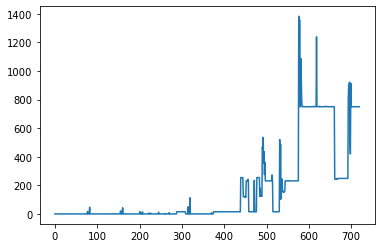

In [7]:
plt.plot(q_one_size)

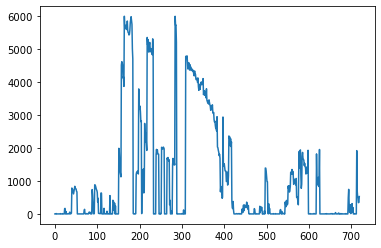

In [8]:
plt.plot(q_two_size)

#### Create the feature enriched dataset for each item

In [9]:
def create_dataset_predict(q_one, q_two):
    """Adds features to the dataframe and returns the prepared dataset containing
    the sample items and the matching target variables
    
    Parameters:
    q_one (pd.DataFrame): dataframe containing entries of the first queue
    q_two (pd.DataFrame): dataframe containing entries of the second queue
    
    Returns:
    data_x (list): list containing the selected sample items
    maxlen (int): length of the dataframe
    """

    # Create MultiLabelBinarized DataFrames for both queues
    mlb = MultiLabelBinarizer()
    q_one_mlb = pd.DataFrame(mlb.fit_transform(q_one['items']), columns=mlb.classes_)
    q_two_mlb = pd.DataFrame(mlb.fit_transform(q_two['items']), columns=mlb.classes_)

    # # Add features: "n_added_items", "n_removed_items" for queue one
    # lists = q_one['items'].tolist()
    # current = lists[0]
    # diff_sets = [[]]
    # diff_sets_rev = [[]]
    # for next_list in lists[1:]:
    #     diff_sets.append(sorted(set(current).difference(set(next_list))))
    #     diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
    #     current = next_list

    # q_one['diff_items'] = diff_sets
    # q_one['diff_items_rev'] = diff_sets_rev
    # q_one['n_removed_items'] = q_one['diff_items'].apply(lambda x: len(x))
    # q_one['n_added_items'] = q_one['diff_items_rev'].apply(lambda x: len(x))

    # Add features: "n_added_items", "n_removed_items" for queue two
    lists = q_two['items'].tolist()
    current = lists[0]
    diff_sets = [[]]
    diff_sets_rev = [[]]
    for next_list in lists[1:]:
        diff_sets.append(sorted(set(current).difference(set(next_list))))
        diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
        current = next_list

    q_two['diff_items'] = diff_sets
    q_two['diff_items_rev'] = diff_sets_rev
    q_two['n_removed_items'] = q_two['diff_items'].apply(lambda x: len(x))
    q_two['n_added_items'] = q_two['diff_items_rev'].apply(lambda x: len(x))

    # Get only the values from each column
    sizes_q_one = q_one['size'].values
#   added_q_two = q_one['n_added_items'].values
#   removed_q_two = q_one['n_removed_items'].values

    sizes_q_two = q_two['size'].values
    added_q_two = q_two['n_added_items'].values
    removed_q_two = q_two['n_removed_items'].values

    # Items to predict, which are left at the last timestamp in both queues
    pred = q_one['items'][-1]+q_two['items'][-1]

    data_x = list()
    #print(len(q_one['items'][-1]))
    #print(len(q_two['items'][-1]))

    
    # Create each sample
    for item in q_one_mlb.columns: #first queue
        if item in pred:
            if item in q_two_mlb.columns:
                # Mask the occurence of the item in both queues
                mask_q_one = q_one_mlb[item] != 0
                mask_q_two = q_two_mlb[item] != 0

                # Get the position it appears in the first queue and the first and last time in the second queue
                position_q_one_first = q_one_mlb[item][mask_q_one].index[0]
                position_q_two_first = q_two_mlb[item][mask_q_two].index[0]
                position_q_two_last = q_two_mlb[item][mask_q_two].index[-1]

                # Filter out odd behaviour (if it first appears in the second and afterwards in the first)
                # and slice the features based on the positions

                if position_q_one_first > position_q_two_last:
                    diff = position_q_two_last - position_q_two_first
                    size_one = sizes_q_one[position_q_two_first:position_q_two_last]
                    size_two = sizes_q_two[position_q_two_first:position_q_two_last]
                    added = added_q_two[position_q_two_first:position_q_two_last]
                    removed = removed_q_two[position_q_two_first:position_q_two_last]
                else:
                    diff = position_q_two_last - position_q_one_first
                    size_one = sizes_q_one[position_q_one_first:position_q_two_last]
                    size_two = sizes_q_two[position_q_one_first:position_q_two_last]
                    added = added_q_two[position_q_one_first:position_q_two_last]
                    removed = removed_q_two[position_q_one_first:position_q_two_last]

                # Create list of steps it stays in the queue
                steps_list = list(range(1, diff+1))

                # Create a dataframe and fill in the features
                X_item = pd.DataFrame(data=steps_list, columns=[item]).astype(str).astype(int)
                X_item['Q_size_one'] = size_one
                X_item['Q_size_two'] = size_two
                X_item['n_added_two'] = added
                X_item['n_removed_two'] = removed
                X_item['Q_start'] = 0 #mark that the item appeared in the first queue

                # Filter out items with no values
                if len(X_item) == 0:
                    continue

                data_x.append(X_item)

            else:
                mask_q_one = q_one_mlb[item] != 0

                position_q_one_first = q_one_mlb[item][mask_q_one].index[0]

                diff = len(q_two_mlb) - position_q_one_first
                size_one = sizes_q_one[position_q_one_first:]
                size_two = sizes_q_two[position_q_one_first:]
                added = added_q_two[position_q_one_first:]
                removed = removed_q_two[position_q_one_first:]
                
                steps_list = list(range(1, diff+1))
                
                # Create a dataframe and fill in the features
                X_item = pd.DataFrame(data=steps_list, columns=[item]).astype(str).astype(int)
                X_item['Q_size_one'] = size_one
                X_item['Q_size_two'] = size_two
                X_item['n_added_two'] = added
                X_item['n_removed_two'] = removed
                X_item['Q_start'] = 0 #mark that the item appeared in the first queue

                data_x.append(X_item)
                
                
    
    print('Items in first and second q: ', len(data_x))

    for item in q_two_mlb.columns:
        if ((item not in q_one_mlb.columns) and (item in pred)):
            
            # Mark the occourence of the item in the queue
            mask_q_two = q_two_mlb[item] != 0
            
            # Get the first and last appearance of the item in the queue
            position_q_two_first = q_two_mlb[item][mask_q_two].index[0]
            position_q_two_last = q_two_mlb[item][mask_q_two].index[-1]
            
            # Slice the features based on the positions
            diff = position_q_two_last - position_q_two_first
            size_one = sizes_q_one[position_q_two_first:position_q_two_last]
            size_two = sizes_q_two[position_q_two_first:position_q_two_last]
            added = added_q_two[position_q_two_first:position_q_two_last]
            removed = removed_q_two[position_q_two_first:position_q_two_last]

            # Create list of steps it stays in the queue
            steps_list = list(range(1, diff+1))

            # Create a dataframe and fill in the features
            X_item = pd.DataFrame(data=steps_list, columns=[item]).astype(str).astype(int)
            X_item['Q_size_one'] = size_one
            X_item['Q_size_two'] = size_two
            X_item['n_added_two'] = added
            X_item['n_removed_two'] = removed
            X_item['Q_start'] = 1 #mark that it didn't appear in the first queue
            # Filter out items with no values
            if len(X_item) == 0:
                continue
            data_x.append(X_item)

        else:
            continue
            
            
    #print(len(pred))
    # maxlen= len(q_two)
    print(len(data_x), 'items in the dataset')
    return data_x


In [10]:
X = create_dataset_predict(q_one, q_two)

750
526
Items in first and second q:  1076
1276
1269 items in the dataset


In [11]:
X[0]

,100169626,Q_size_one,Q_size_two,n_added_two,n_removed_two,Q_start
0,1,1382,1338,1338,276,0
1,2,750,1891,912,359,0
2,3,1357,1395,350,846,0
3,4,778,1919,847,323,0
4,5,750,1938,79,60,0
...,...,...,...,...,...,...
139,140,750,535,0,184,0
140,141,750,492,1,44,0
141,142,750,340,5,157,0
142,143,750,350,10,0,0


#### Padding

In [12]:
def scale_pad(dataset, maxlen):
    '''Scales and pads the sequences (samples)
    
    Parameters:
    dataset (list): list containing the samples
    maxlen (int): max number of timesteps/value to pad
    
    Returns:
    X_pad_scaled (list): list with padded and scaled sequences
    X_pad (list): list with padded sequences'''
    
    # Load the scaler used for training
    scaler_X = pickle.load(open("scaler_x_2q.p", "rb"))
    
    # Scale the dataset
    X_scaled = [scaler_X.transform(x) for x in dataset]
    
    
    # Pad the sequences
    def pad(sequence, maxlen):
        # fills list post (at the end) with 0s to make even sized sequences
        return pad_sequences(sequence, maxlen=maxlen, dtype='float32', padding='post', value=0.0)

    X_pad_scaled = pad([x for x in X_scaled], maxlen)
    X_pad = pad([x.values for x in dataset], maxlen)
    
    return X_pad_scaled, X_pad

In [13]:
X_pad_scaled, X_pad = scale_pad(X, 720)

#### Load Model

In [14]:
# Load the pretrained model, predict and rescale the prediction
model = load_model("model_2q_best_outlier.h5")
pred = model.predict(X_pad_scaled)
scaler_y = pickle.load(open("scaler_y_2q_outlier.p", "rb"))
pred_rescaled = scaler_y.inverse_transform(pred.reshape(-1, 1)).reshape(pred.shape)

# Create a list containing the maximum number of steps for each item
max_steps = list()
for item in X_pad:
    max_step = max(item[:,0])
    max_steps.append(max_step)

# Create lists containing the predictions and corresponding item numbers
pred_list = list()
pred_only = list()
for x in range(len(X_pad)):
    predict = (int(pred_rescaled[x][int(max_steps[x]-1)])) #take the prediction at the last step
    item = X[x].columns[0] #get the item number
    item_predict = [item, predict]
    pred_list.append(item_predict)
    pred_only.append(predict)

# Create the final list to match the ES structure
final_list = list()

for x in range(int(max(pred_only))):
    items = ''
    for prediction in pred_list:
        if prediction[1] >= x:
            item = prediction[0] + ' '
            items += item
    final_list.append(items)  

# Create the final DataFrame
final_df = pd.DataFrame()
final_df['items'] = final_list
final_df['size'] = final_df['items'].apply(lambda x: len(x.split(" "))-1) #calculate the size based on items

# Generate timestamps based on the last timestamp
time_stamps = pd.date_range(start=q_two.index[-1]+datetime.timedelta(minutes=10), periods=len(final_df), freq='10min')
final_df['timestamp'] = time_stamps
final_df['timestamp'] = final_df.timestamp.map(lambda x: datetime.datetime.strftime(x, '%Y-%m-%dT%H:%M:%S.%f%z'))

In [15]:
final_df['size'].values

array([1269, 1269, 1269, 1268, 1267, 1267, 1077, 1077, 1076, 1076, 1076,
       1066, 1053, 1052,  328,  259,  255,  255,  255,  253,  243,  237,
        236,  229,  227,  221,  219,  216,  197,  195,  194,  193,  191,
        146,  146,  111,   91,   69,   67,   67,   67,   67,   67,   65,
         65,   65,   60,   60,   60,   58,   58,   58,   58,   58,   58,
         58,   58,   58,   58,   58,   58,   58,   58,   56,   56,   51,
         51,   50,   50,   42,   42,   42,   42,   31,   31,   31,   31,
         29,   29,   29,   29,   29,   29,   29,   29,   28,   28,   28,
         28,   27,   27,   26,   26,   26,   26,   26,   26,   26,   26,
         25,   24,   24,   23,   23,   23,   23,   23,   22,   22,   22,
         22,   22,   22,   22,   22,   21,   21,   20,   19,   19,   18,
         18,   16,   16,   16,   16,   16,   16,   16,   16,   16,   16,
         16,   16,   16,   16,   16,   16,    9,    9,    9,    8,    5,
          4,    4,    3,    3,    3,    3,    3,   

In [16]:
q_two.index[-1]

Timestamp('2020-06-13 23:50:32.669329+0000', tz='UTC')

In [17]:
final_df.head()

,items,size,timestamp
0,100169626 1006833586 1010184859 1013459793 101...,1269,2020-06-14T00:00:32.669329+0000
1,100169626 1006833586 1010184859 1013459793 101...,1269,2020-06-14T00:10:32.669329+0000
2,100169626 1006833586 1010184859 1013459793 101...,1269,2020-06-14T00:20:32.669329+0000
3,100169626 1006833586 1010184859 1013459793 101...,1268,2020-06-14T00:30:32.669329+0000
4,100169626 1006833586 1010184859 1013459793 101...,1267,2020-06-14T00:40:32.669329+0000


In [18]:
q_two_test = es_to_df("2020-06-14","2020-06-17", 20, "pic", 'localhost', 9200)

In [19]:
len(final_df)

201

In [20]:
len(q_two_test)

576

In [21]:
real_size = q_two_test['size'].values[:366]

In [22]:
item_size = final_df['size'].values

In [23]:
import matplotlib.pyplot as plt

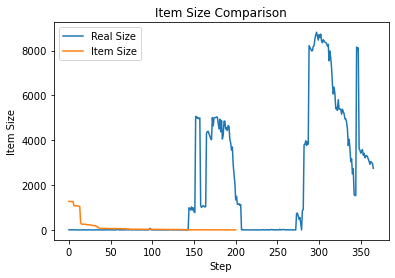

In [24]:
plt.plot(real_size, label='Real Size')
plt.plot(item_size, label='Item Size')
plt.title('Item Size Comparison')
plt.xlabel('Step')
plt.ylabel('Item Size')
plt.legend()
plt.show()